### Deriving the non-linear plate TSDT kinematics

In [1]:
from sympy import Function, Symbol, sqrt
from sympy import init_printing, expand

x = Symbol('x')
y = Symbol('y')
z = Symbol('z')
h = Symbol('h')
u0 = Function('u')(x,y)
v0 = Function('v')(x,y)
w = Function('w')(x,y)
phix = Function('phi_x')(x,y)
phiy = Function('phi_y')(x,y)

# TSDT constraints
u = u0 + z*phix - 4/(3*h**2)*z**3*(phix + w.diff(x))
v = v0 + z*phiy - 4/(3*h**2)*z**3*(phiy + w.diff(y))

NL = 0 # NOTE set to 1 for full nonlinear relations, 0 for linear relations

# Global coordinates
X1 = x
X2 = y
X3 = z

# Local coordinates
x1 = x
x2 = y
x3 = z

H1 = sqrt(X1.diff(x1)**2 + X2.diff(x1)**2 + X3.diff(x1)**2)
H2 = sqrt(X1.diff(x2)**2 + X2.diff(x2)**2 + X3.diff(x2)**2)
H3 = sqrt(X1.diff(x3)**2 + X2.diff(x3)**2 + X3.diff(x3)**2)
                
w1 = ((H1*w).diff(x2) - (H2*v).diff(x3))/(2*H2*H3)
w2 = ((H1*u).diff(x3) - (H3*w).diff(x1))/(2*H1*H3)
w3 = ((H2*v).diff(x1) - (H1*u).diff(x2))/(2*H1*H2)

e11 = u.diff(x1)/H1 + v*H1.diff(x2)/(H1*H2) + w*H1.diff(x3)/(H1*H3)
e22 = u*H2.diff(x1)/(H1*H2) + v.diff(x2)/H2 + w*H2.diff(x3)/(H2*H3)
e33 = u*H3.diff(x1)/(H1*H3) + v*H3.diff(x2)/(H2*H3) + w.diff(x3)/H3
e12 = H1*(u/H1).diff(x2)/H2 + H2*(v/H2).diff(x1)/H1
e13 = H1*(u/H1).diff(x3)/H3 + H3*(w/H3).diff(x1)/H1
e23 = H2*(v/H2).diff(x3)/H3 + H3*(w/H3).diff(x2)/H2

ep11 = ((e13/2 - w2)**2 + (e12/2 + w3)**2 + e11**2)/2*NL + e11
ep22 = ((e23/2 + w1)**2 + (e12/2 - w3)**2 + e22**2)/2*NL + e22
ep33 = ((e23/2 - w1)**2 + (e13/2 + w2)**2 + e33**2)/2*NL + e33
ep12 = ((e23/2 + w1)*(e13/2 - w2) + e11*(e12/2 - w3) + e22*(e12/2 + w3))*NL + e12
ep13 = (e33*(e13/2 - w2) + e11*(e13/2 + w2) + (e23/2 - w1)*(e12/2 + w3))*NL + e13
ep23 = (e22*(e23/2 - w1) + e33*(e23/2 + w1) + (e13/2 + w2)*(e12/2 - w3))*NL + e23

exx = ep11
eyy = ep22
ezz = ep33
gxy = ep12
gxz = ep13
gyz = ep23



Printing kinematic equations
---
The following order is printed next:

$\varepsilon_{xx}$
$\varepsilon_{yy}$
$\varepsilon_{zz}$
$\gamma_{xy}$
$\gamma_{xz}$
$\gamma_{yz}$


In [2]:
init_printing()

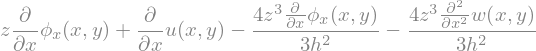

In [3]:
expand(exx)

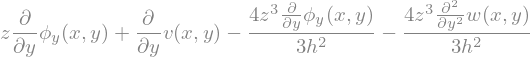

In [4]:
expand(eyy)

In [6]:
expand(ezz)

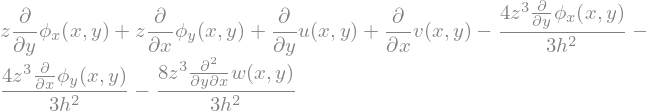

In [7]:
expand(gxy)

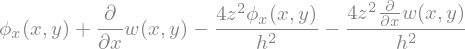

In [8]:
expand(gxz)

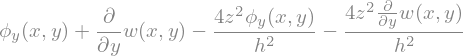

In [9]:
expand(gyz)